**GABS Project**

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Load connectomes
alzheimer = np.load('../Data/project1.npy')  # (46, 96, 96)
healthy = np.load('../Data/project2.npy')    # (42, 96, 96)

print(f"Alzheimer's: {alzheimer.shape[0]} subjects, {alzheimer.shape[1]}x{alzheimer.shape[2]} parcels")
print(f"Healthy Controls: {healthy.shape[0]} subjects, {healthy.shape[1]}x{healthy.shape[2]} parcels")

Alzheimer's: 46 subjects, 96x96 parcels
Healthy Controls: 42 subjects, 96x96 parcels


## 1. Mean Connectomes: Alzheimer's vs Healthy Controls

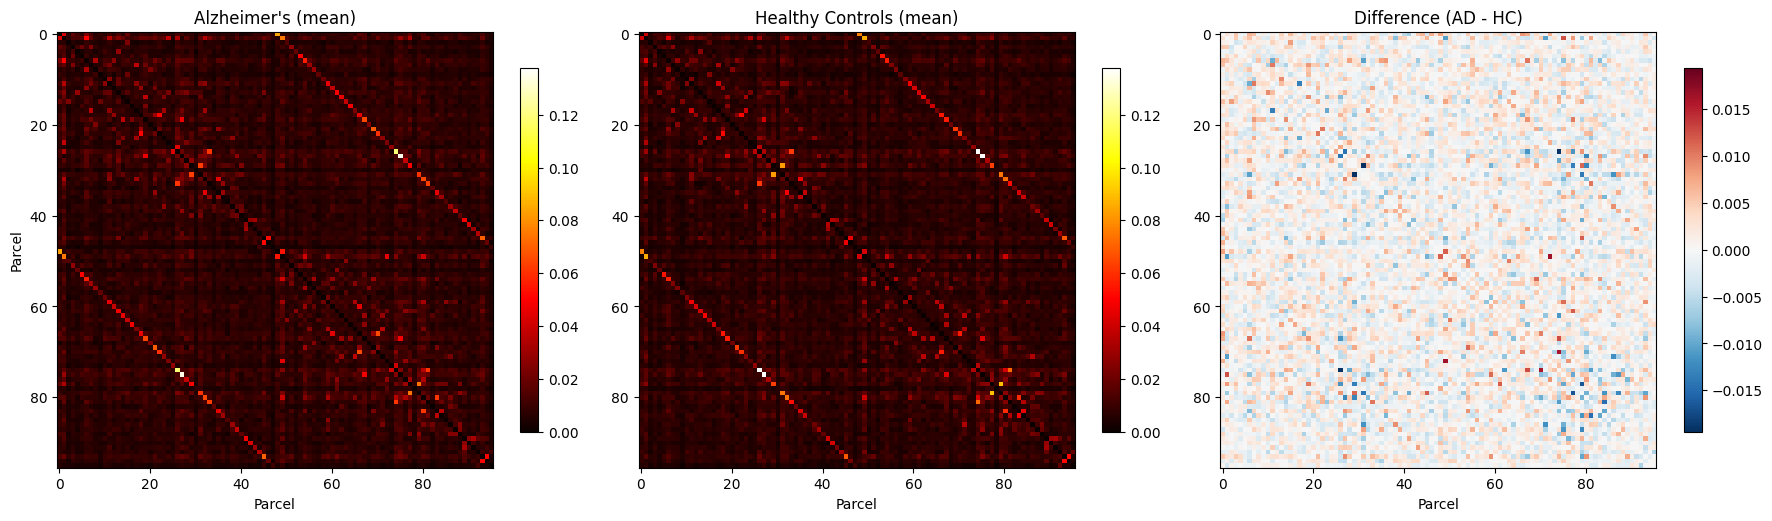

In [9]:
mean_alz = alzheimer.mean(axis=0)
mean_hc = healthy.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(mean_alz, cmap='hot', vmin=0, vmax=max(mean_alz.max(), mean_hc.max()))
axes[0].set_title("Alzheimer's (mean)")
axes[0].set_xlabel('Parcel')
axes[0].set_ylabel('Parcel')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(mean_hc, cmap='hot', vmin=0, vmax=max(mean_alz.max(), mean_hc.max()))
axes[1].set_title('Healthy Controls (mean)')
axes[1].set_xlabel('Parcel')
plt.colorbar(im1, ax=axes[1], shrink=0.8)
1
diff = mean_alz - mean_hc
lim = np.abs(diff).max()
im2 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-lim, vmax=lim)
axes[2].set_title('Difference (AD - HC)')
axes[2].set_xlabel('Parcel')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

## 2. Distribution of Connection Strengths

Each subject's connectome is a 96×96 matrix. Each entry is a number representing how strongly two brain regions are connected structurally (derived from diffusion imaging). A higher value means a stronger connection.

Here we take all ~4500 unique connection weights (upper triangle) across all subjects and plot how many are weak vs strong. The two groups (AD and HC) are overlaid so we can see if Alzheimer's brains have a different pattern — e.g., fewer strong connections. The log-scale plot on the right makes it easier to see rare strong connections.

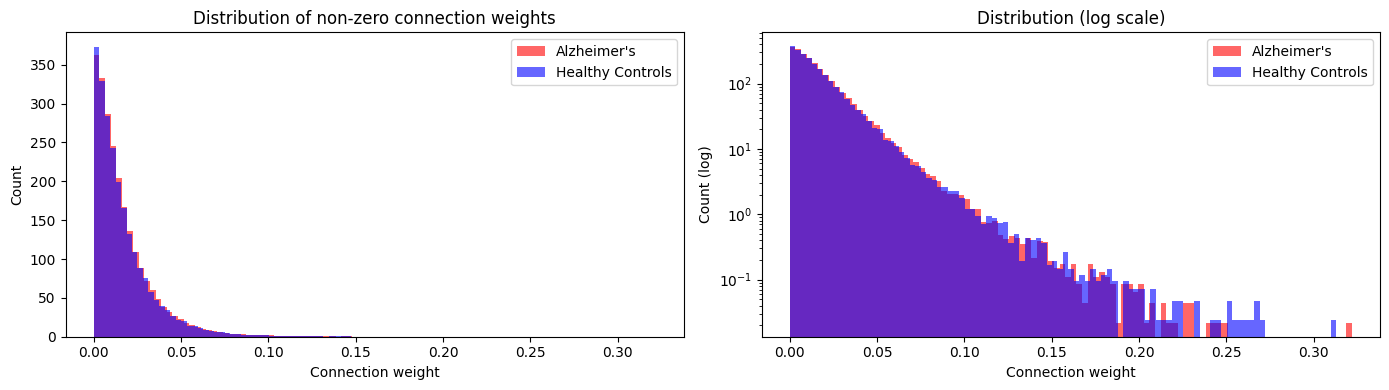

In [17]:
# Distribution of non-zero connection weights (upper triangle to avoid duplicates)
triu_idx = np.triu_indices(96, k=1)

alz_weights = alzheimer[:, triu_idx[0], triu_idx[1]].flatten()
hc_weights = healthy[:, triu_idx[0], triu_idx[1]].flatten()

# Filter out zeros for cleaner histogram
alz_nonzero = alz_weights[alz_weights > 0]
hc_nonzero = hc_weights[hc_weights > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(alz_nonzero, bins=100, alpha=0.6, label="Alzheimer's", color='red',weights=np.ones_like(alz_nonzero)/46)
axes[0].hist(hc_nonzero, bins=100, alpha=0.6, label='Healthy Controls', color='blue',weights=np.ones_like(hc_nonzero)/42)
axes[0].set_xlabel('Connection weight')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of non-zero connection weights')
axes[0].legend()

# Log scale for better visibility of tails
axes[1].hist(alz_nonzero, bins=100, alpha=0.6, label="Alzheimer's", color='red',weights=np.ones_like(alz_nonzero)/46)
axes[1].hist(hc_nonzero, bins=100, alpha=0.6, label='Healthy Controls', color='blue',weights=np.ones_like(hc_nonzero)/42)
axes[1].set_xlabel('Connection weight')
axes[1].set_ylabel('Count (log)')
axes[1].set_yscale('log')
axes[1].set_title('Distribution (log scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Node Strength (Degree) Comparison

Node strength is the sum of all connection weights for a single brain region (parcel). It tells us how well-connected that region is to the rest of the brain — a high value means that region has many strong connections.

We compute this for each of the 96 parcels, averaged across subjects. The left plot compares AD vs HC side by side. The right plot shows the difference: red bars mean AD has stronger connectivity at that parcel, blue means HC is stronger. This helps identify which specific brain regions are most affected in Alzheimer's.

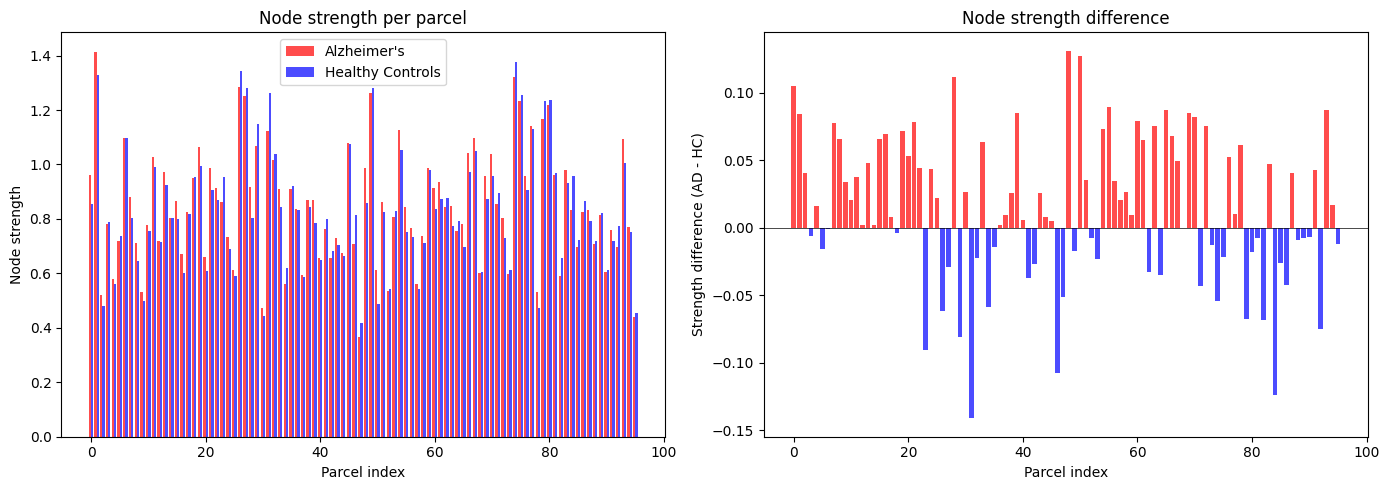

In [ ]:
# Node strength = sum of connection weights per parcel
alz_strength = alzheimer.sum(axis=2).mean(axis=0)  # mean across subjects, per parcel
hc_strength = healthy.sum(axis=2).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of node strengths
x = np.arange(96)
axes[0].bar(x - 0.2, alz_strength, width=0.4, label="Alzheimer's", color='red', alpha=0.7)
axes[0].bar(x + 0.2, hc_strength, width=0.4, label='Healthy Controls', color='blue', alpha=0.7)
axes[0].set_xlabel('Parcel index')
axes[0].set_ylabel('Node strength')
axes[0].set_title('Node strength per parcel')
axes[0].legend()

# Difference in node strength
strength_diff = alz_strength - hc_strength
colors = ['red' if d > 0 else 'blue' for d in strength_diff]
axes[1].bar(x, strength_diff, color=colors, alpha=0.7)
axes[1].set_xlabel('Parcel index')
axes[1].set_ylabel('Strength difference (AD - HC)')
axes[1].set_title('Node strength difference')
axes[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## 4. Individual Subject Variability (Total Connection Strength per Subject)

Here we collapse each subject's entire 96×96 connectome into a single number by summing all weights. This is a rough measure of overall "how connected" that person's brain is.

The boxplot shows the distribution for each group (median, spread, outliers). The strip plot shows each subject as a dot. This lets us check two things: (1) whether AD subjects tend to have weaker total connectivity than HC, and (2) how much variation there is within each group.

/var/folders/h_/dp4gh3q90g74bjdgwh15z_th0000gn/T/ipykernel_55286/2452401935.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([alz_total, hc_total], labels=["Alzheimer's", "Healthy Controls"])


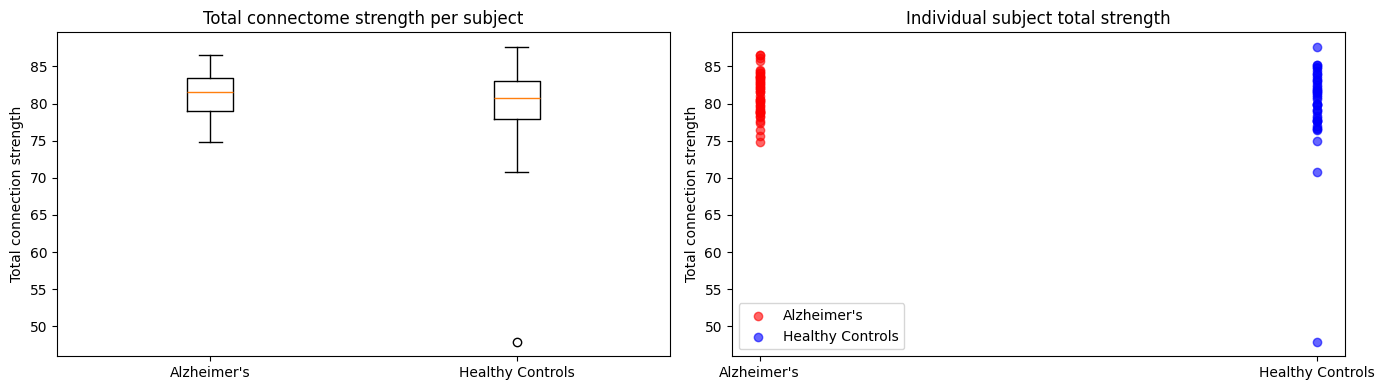

Alzheimer's: mean=81.30, std=2.83
Healthy Controls: mean=79.83, std=5.97


In [ ]:
# Total connection strength per subject
alz_total = alzheimer.sum(axis=(1, 2))
hc_total = healthy.sum(axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Box plot
axes[0].boxplot([alz_total, hc_total], labels=["Alzheimer's", "Healthy Controls"])
axes[0].set_ylabel('Total connection strength')
axes[0].set_title('Total connectome strength per subject')

# Scatter / strip plot
axes[1].scatter(np.zeros(len(alz_total)), alz_total, alpha=0.6, color='red', label="Alzheimer's")
axes[1].scatter(np.ones(len(hc_total)), hc_total, alpha=0.6, color='blue', label='Healthy Controls')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Alzheimer's", "Healthy Controls"])
axes[1].set_ylabel('Total connection strength')
axes[1].set_title('Individual subject total strength')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Alzheimer's: mean={alz_total.mean():.2f}, std={alz_total.std():.2f}")
print(f"Healthy Controls: mean={hc_total.mean():.2f}, std={hc_total.std():.2f}")

## 5. Example Single-Subject Connectomes

/var/folders/h_/dp4gh3q90g74bjdgwh15z_th0000gn/T/ipykernel_55286/547883646.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


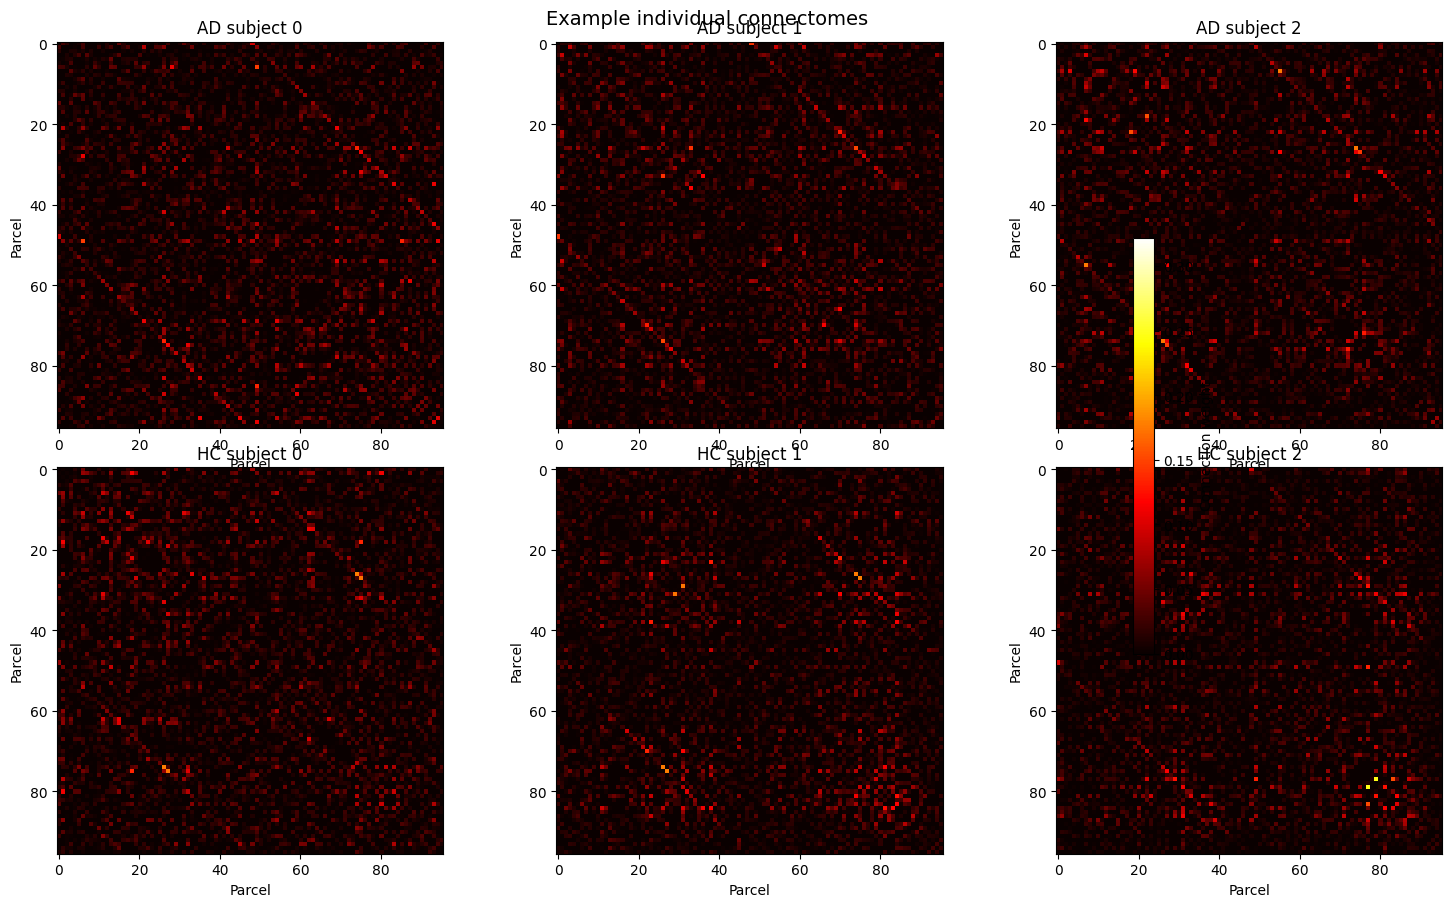

In [ ]:
# Show 3 example subjects from each group
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
vmax = max(alzheimer.max(), healthy.max())

for i in range(3):
    im = axes[0, i].imshow(alzheimer[i], cmap='hot', vmin=0, vmax=vmax)
    axes[0, i].set_title(f'AD subject {i}')
    axes[0, i].set_xlabel('Parcel')
    axes[0, i].set_ylabel('Parcel')

    im = axes[1, i].imshow(healthy[i], cmap='hot', vmin=0, vmax=vmax)
    axes[1, i].set_title(f'HC subject {i}')
    axes[1, i].set_xlabel('Parcel')
    axes[1, i].set_ylabel('Parcel')

fig.colorbar(im, ax=axes, shrink=0.6, label='Connection weight')
plt.suptitle('Example individual connectomes', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Kuramoto Simulation

We use the hierarchical Kuramoto model from Exercise B. Each subject's structural connectome (96×96) is used as the `weight_matrix`, scaled by the global coupling parameter L. The model simulates oscillatory brain activity based on the structural connectivity.

Parameters (from the project instructions):
- **L = 15.0** (global coupling, scales the connectome)
- **K = 24.0–24.5** (local coupling within nodes)
- **96 nodes** (one per parcel), 100 oscillators each
- **10 Hz** central frequency, sampling rate 200 Hz

We simulate one example subject from each group first to inspect the output, then scale up.

In [7]:
import sys
sys.path.insert(0, '.')
from kuramoto_course_silicon import KuramotoFast

# Simulation parameters
n_nodes = 96
n_oscillators = 100
sampling_rate = 200
frequency_spread = 3
node_frequencies = [10.0] * n_nodes

L = 15.0
K = 24.0

use_accel = True  # set to True if you have a GPU

sim_time = 300  # short run for quick inspection; use 600 (10 min) for DFA

# Simulate one AD subject
model_ad = KuramotoFast(
    n_nodes=n_nodes, n_oscillators=n_oscillators,
    k_list=[K] * n_nodes,
    weight_matrix=alzheimer[0] * L,
    node_frequencies=node_frequencies,
    sampling_rate=sampling_rate, frequency_spread=frequency_spread,
    use_accel=use_accel
)
data_ad = model_ad.simulate(time=sim_time)

# Simulate one HC subject
model_hc = KuramotoFast(
    n_nodes=n_nodes, n_oscillators=n_oscillators,
    k_list=[K] * n_nodes,
    weight_matrix=healthy[0] * L,
    node_frequencies=node_frequencies,
    sampling_rate=sampling_rate, frequency_spread=frequency_spread,
    use_accel=use_accel
)
data_hc = model_hc.simulate(time=sim_time)

print(f"AD simulation shape: {data_ad.shape}")
print(f"HC simulation shape: {data_hc.shape}")

KeyboardInterrupt: 

### Timeseries: Real part, Imaginary part, and Amplitude

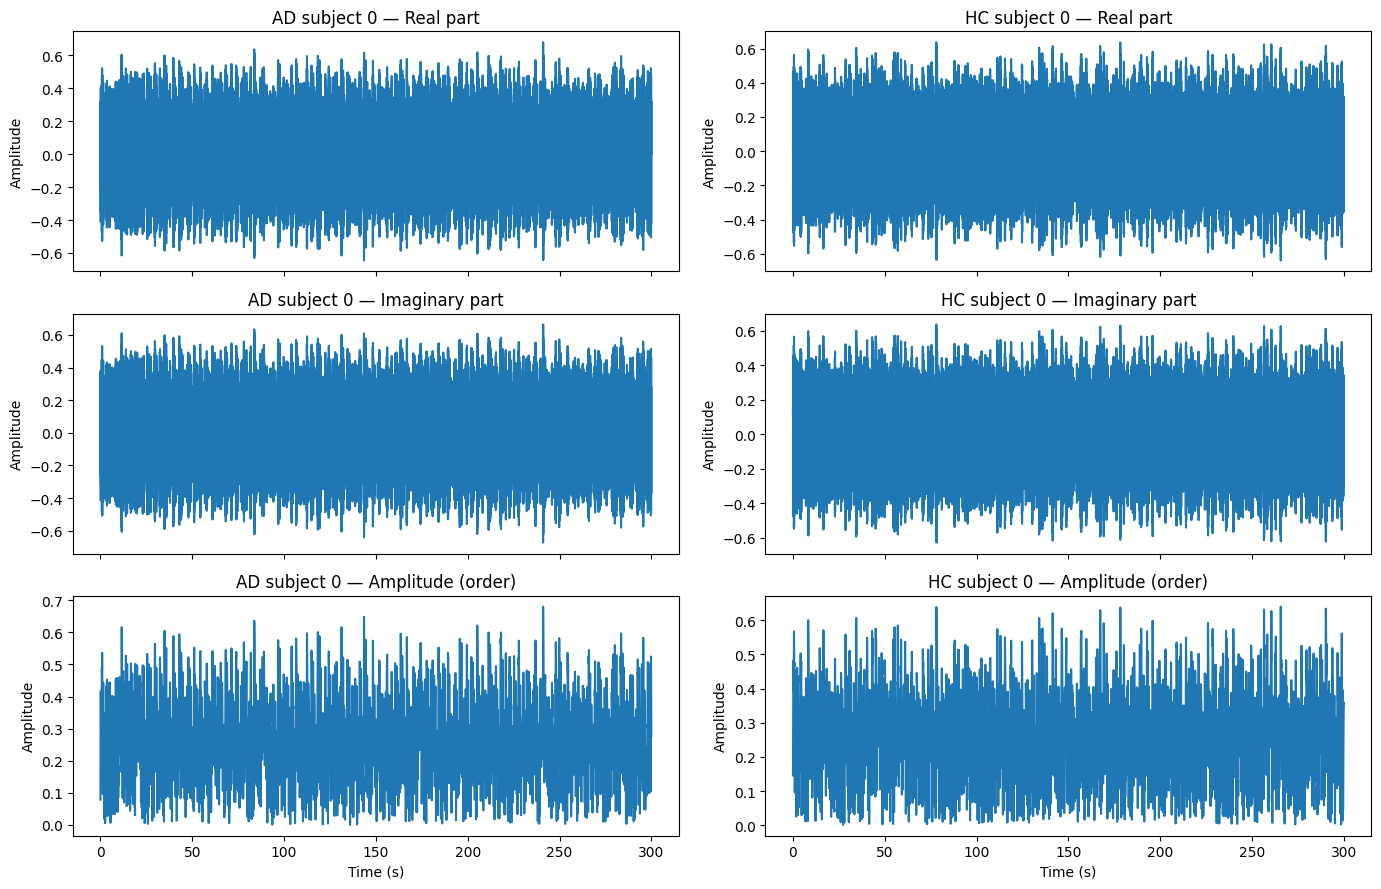

In [ ]:
t = np.arange(data_ad.shape[1]) / sampling_rate

fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)

for col, (data, label) in enumerate([(data_ad, 'AD subject 0'), (data_hc, 'HC subject 0')]):
    node = data[0]  # first node
    axes[0, col].plot(t, np.real(node))
    axes[0, col].set_ylabel('Amplitude')
    axes[0, col].set_title(f'{label} — Real part')

    axes[1, col].plot(t, np.imag(node))
    axes[1, col].set_ylabel('Amplitude')
    axes[1, col].set_title(f'{label} — Imaginary part')

    axes[2, col].plot(t, np.abs(node))
    axes[2, col].set_ylabel('Amplitude')
    axes[2, col].set_title(f'{label} — Amplitude (order)')

axes[2, 0].set_xlabel('Time (s)')
axes[2, 1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

### Power Spectral Density

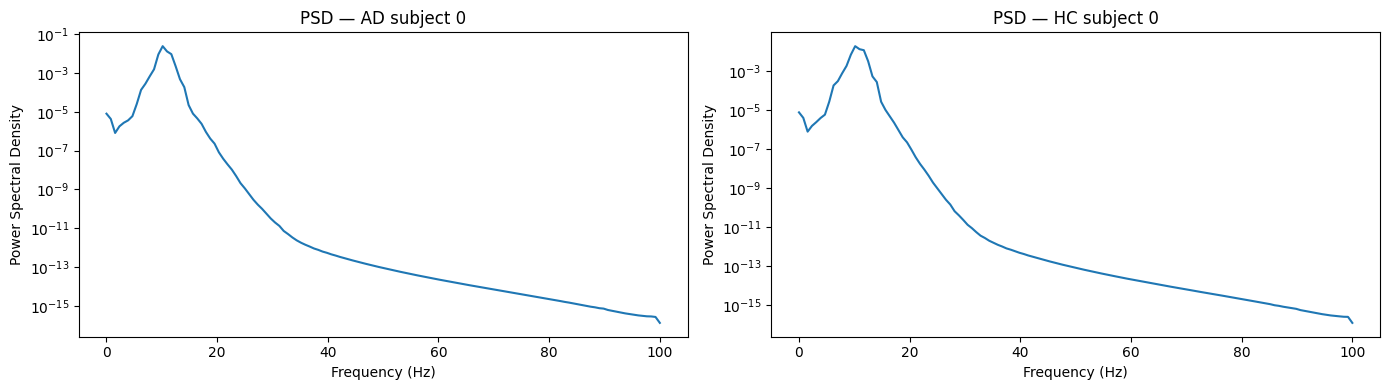

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (data, label) in zip(axes, [(data_ad, 'AD subject 0'), (data_hc, 'HC subject 0')]):
    freqs, psd = signal.welch(np.real(data[0]), fs=sampling_rate)
    ax.semilogy(freqs, psd)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power Spectral Density')
    ax.set_title(f'PSD — {label}')

plt.tight_layout()
plt.show()

### PLV between nodes

/var/folders/h_/dp4gh3q90g74bjdgwh15z_th0000gn/T/ipykernel_47422/1025353049.py:4: RuntimeWarning: divide by zero encountered in matmul
  plv_matrix = np.abs(z @ z.conj().T) / data.shape[1]
/var/folders/h_/dp4gh3q90g74bjdgwh15z_th0000gn/T/ipykernel_47422/1025353049.py:4: RuntimeWarning: overflow encountered in matmul
  plv_matrix = np.abs(z @ z.conj().T) / data.shape[1]
/var/folders/h_/dp4gh3q90g74bjdgwh15z_th0000gn/T/ipykernel_47422/1025353049.py:4: RuntimeWarning: invalid value encountered in matmul
  plv_matrix = np.abs(z @ z.conj().T) / data.shape[1]


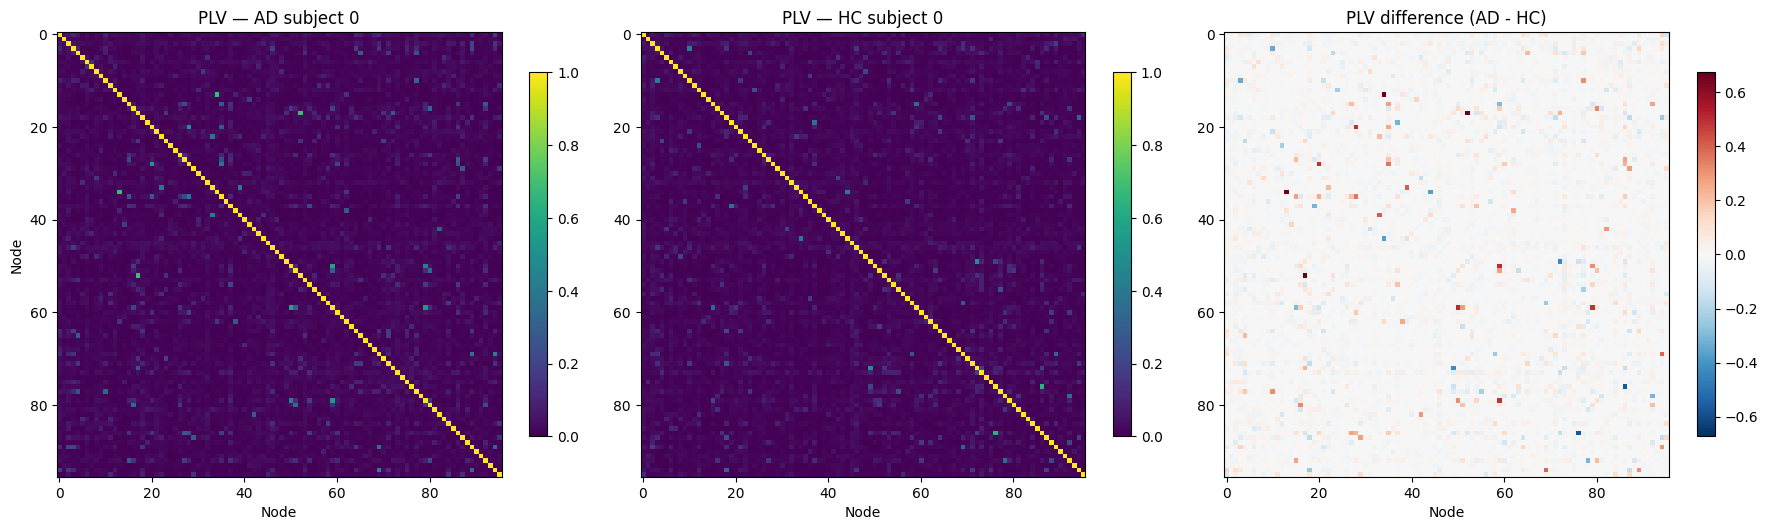

In [ ]:
def compute_plv(data):
    """Compute PLV matrix from analytical signal (n_nodes x n_timepoints)."""
    z = data / np.abs(data)
    plv_matrix = np.abs(z @ z.conj().T) / data.shape[1]
    return plv_matrix

plv_ad = compute_plv(data_ad)
plv_hc = compute_plv(data_hc)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(plv_ad, cmap='viridis', vmin=0, vmax=1)
axes[0].set_title('PLV — AD subject 0')
axes[0].set_xlabel('Node')
axes[0].set_ylabel('Node')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].imshow(plv_hc, cmap='viridis', vmin=0, vmax=1)
axes[1].set_title('PLV — HC subject 0')
axes[1].set_xlabel('Node')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

plv_diff = plv_ad - plv_hc
lim = np.abs(plv_diff).max()
im2 = axes[2].imshow(plv_diff, cmap='RdBu_r', vmin=-lim, vmax=lim)
axes[2].set_title('PLV difference (AD - HC)')
axes[2].set_xlabel('Node')
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

### Order Parameter (mean synchronization across nodes)

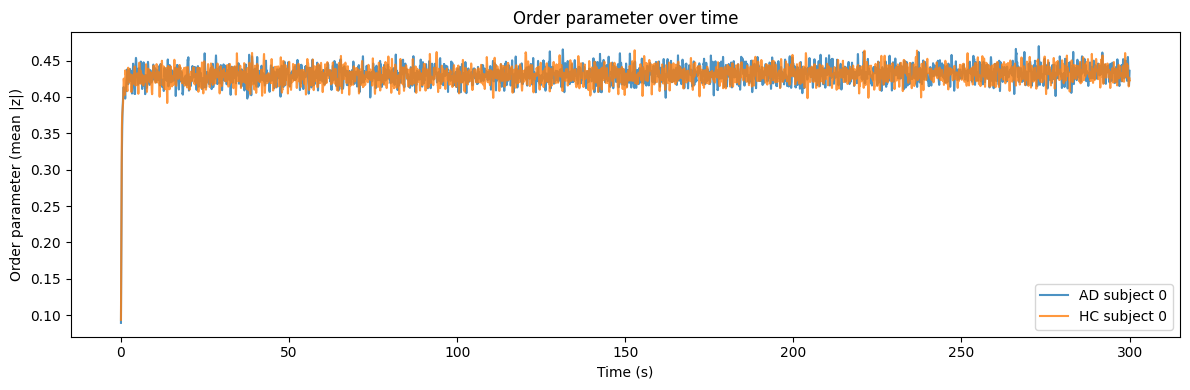

AD — mean order: 0.4310, std: 0.0123
HC — mean order: 0.4301, std: 0.0117


In [ ]:
# Order = mean |z| across nodes over time
order_ad = np.abs(data_ad).mean(axis=0)
order_hc = np.abs(data_hc).mean(axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, order_ad, label='AD subject 0', alpha=0.8)
ax.plot(t, order_hc, label='HC subject 0', alpha=0.8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Order parameter (mean |z|)')
ax.set_title('Order parameter over time')
ax.legend()
plt.tight_layout()
plt.show()

print(f"AD — mean order: {order_ad.mean():.4f}, std: {order_ad.std():.4f}")
print(f"HC — mean order: {order_hc.mean():.4f}, std: {order_hc.std():.4f}")

## 7. K-sweep: Finding the Critical Coupling

We sweep the local coupling K while keeping L=15.0 fixed, and measure the order parameter and its variability for one AD and one HC subject. This reveals where the phase transition (subcritical → critical → supercritical) occurs for each group.

We use the mean connectome for each group to get a representative result. The sweep focuses on K=20–28 (around the suggested range of 24.0–24.5).

In [ ]:
k_values = np.linspace(20, 28, 17)  # 17 steps around the critical region

L = 15.0
#sim_time = 300  # keep short for the sweep; increase for final results
use_accel = True  # set to True if you have a GPU

# Use mean connectomes as representative weight matrices
mean_alz = alzheimer.mean(axis=0)
mean_hc = healthy.mean(axis=0)

results = {'AD': {'order': [], 'variability': []},
           'HC': {'order': [], 'variability': []}}

for k in k_values:
    for group, connectome in [('AD', mean_alz), ('HC', mean_hc)]:
        model = KuramotoFast(
            n_nodes=n_nodes, n_oscillators=n_oscillators,
            k_list=[k] * n_nodes,
            weight_matrix=connectome * L,
            node_frequencies=node_frequencies,
            sampling_rate=sampling_rate, frequency_spread=frequency_spread,
            use_accel=use_accel, use_tqdm=False
        )
        data = model.simulate(time=sim_time)

        order = np.abs(data).mean()
        variability = np.abs(data).std(axis=1).mean()

        results[group]['order'].append(order)
        results[group]['variability'].append(variability)

    print(f"K={k:.1f} done")

K=20.0 done
K=20.5 done
K=21.0 done
K=21.5 done
K=22.0 done
K=22.5 done
K=23.0 done
K=23.5 done
K=24.0 done
K=24.5 done
K=25.0 done
K=25.5 done
K=26.0 done
K=26.5 done
K=27.0 done
K=27.5 done
K=28.0 done


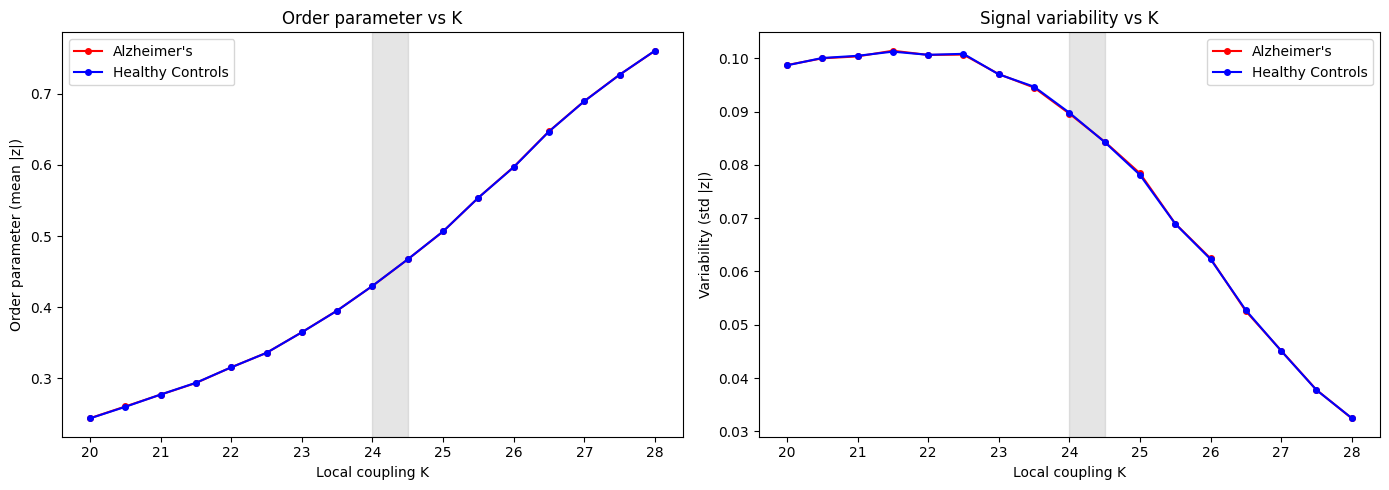

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Order parameter
ax1.plot(k_values, results['AD']['order'], 'r-o', markersize=4, label="Alzheimer's")
ax1.plot(k_values, results['HC']['order'], 'b-o', markersize=4, label='Healthy Controls')
ax1.set_xlabel('Local coupling K')
ax1.set_ylabel('Order parameter (mean |z|)')
ax1.set_title('Order parameter vs K')
ax1.legend()
ax1.axvspan(24.0, 24.5, alpha=0.2, color='grey', label='Suggested K range')

# Variability (indicator of criticality — peaks near the transition)
ax2.plot(k_values, results['AD']['variability'], 'r-o', markersize=4, label="Alzheimer's")
ax2.plot(k_values, results['HC']['variability'], 'b-o', markersize=4, label='Healthy Controls')
ax2.set_xlabel('Local coupling K')
ax2.set_ylabel('Variability (std |z|)')
ax2.set_title('Signal variability vs K')
ax2.legend()
ax2.axvspan(24.0, 24.5, alpha=0.2, color='grey', label='Suggested K range')

plt.tight_layout()
plt.show()

## 8. DFA (Detrended Fluctuation Analysis)

DFA measures long-range temporal correlations in the order parameter time series. The exponent α tells us about the dynamical regime:
- **α ≈ 0.5** → white noise (subcritical, no correlations)
- **0.5 < α < 1** → correlated noise (near criticality)
- **α ≈ 1.5** → Brownian motion (supercritical)

We apply DFA to the amplitude envelope (|z|) of the Kuramoto output. This requires long simulations (10 min / 600s) for reliable results. The functions are taken from Exercise C.

In [ ]:
from tqdm.notebook import tqdm

# %% [markdown]
# ## 8. DFA (Detrended Fluctuation Analysis) - Vectorized

from tqdm.auto import tqdm

def compute_Fn_fast(X, n):
    """Vectorized computation of fluctuation function for non-overlapping windows."""
    
    # 1. MEMORY FIX: Calculate how many non-overlapping windows fit in the signal
    n_windows = len(X) // n
    if n_windows == 0:
        return np.nan
        
    # Truncate the tail end of the signal so it divides evenly
    X_trunc = X[:n_windows * n]
    
    # Reshape into distinct blocks instead of overlapping views
    Xn = X_trunc.reshape(n_windows, n)
    
    # Time vector for the window
    t = np.arange(n)
    t_mean = np.mean(t)
    t_centered = t - t_mean
    var_t = np.sum(t_centered**2)
    
    # Vectorized Linear Regression across all segments at once
    seg_mean = np.mean(Xn, axis=1, keepdims=True)
    seg_centered = Xn - seg_mean
    
    # Calculate slopes and intercepts for all windows simultaneously
    slope = np.dot(seg_centered, t_centered) / var_t
    intercept = np.squeeze(seg_mean) - slope * t_mean
    
    # Reconstruct the fitted lines
    Y_fit = slope[:, None] * t + intercept[:, None]
    
    # Calculate the root sum of squares for each window
    F_n = np.sqrt(np.sum((Xn - Y_fit) ** 2, axis=1))
    
    return np.mean(F_n)

def compute_F(X, segment_sizes):
    """Compute fluctuation function F for multiple segment sizes."""
    n_parcels = X.shape[0]
    F = np.zeros((n_parcels, segment_sizes.shape[0]))
    
    # 1. Integrate the signal (Cumulative sum)
    X_int = np.cumsum(X - np.mean(X, axis=1, keepdims=True), axis=1)
    
    for parc in tqdm(range(n_parcels), desc="Computing DFA"):
        for i, n in enumerate(segment_sizes):
            F[parc, i] = compute_Fn_fast(X_int[parc], n)
            
    return F.mean(axis=0)

def compute_DFA(segment_sizes, F, fitting_range):
    """Compute DFA exponent alpha from fluctuation function."""
    idx = (segment_sizes > fitting_range[0]) & (segment_sizes < fitting_range[1])
    alpha, intercept = np.polyfit(np.log10(segment_sizes[idx]), np.log10(F[idx]), 1)
    return alpha, intercept

### Run long simulations (10 min) for DFA

In [ ]:
L = 15.0
K = 24.0
#sim_time = 600  # 10 minutes
use_accel = True  # set to True if you have a GPU

# AD subject
model_ad_long = KuramotoFast(
    n_nodes=n_nodes, n_oscillators=n_oscillators,
    k_list=[K] * n_nodes,
    weight_matrix=alzheimer[0] * L,
    node_frequencies=node_frequencies,
    sampling_rate=sampling_rate, frequency_spread=frequency_spread,
    use_accel=use_accel
)
data_ad_long = model_ad_long.simulate(time=sim_time)
print(f"AD done: {data_ad_long.shape}")

# HC subject
model_hc_long = KuramotoFast(
    n_nodes=n_nodes, n_oscillators=n_oscillators,
    k_list=[K] * n_nodes,
    weight_matrix=healthy[0] * L,
    node_frequencies=node_frequencies,
    sampling_rate=sampling_rate, frequency_spread=frequency_spread,
    use_accel=use_accel
)
data_hc_long = model_hc_long.simulate(time=sim_time)
print(f"HC done: {data_hc_long.shape}")

AD done: (96, 60001)


HC done: (96, 60001)


### Compute DFA

In [ ]:
# Amplitude envelope = order parameter per node
amp_ad = np.abs(data_ad_long)  # (96, 120001)
amp_hc = np.abs(data_hc_long)

# Use 5 parcels to keep computation manageable (same as Exercise C)
n_parcels_dfa = 5
freq = 10

# Segment sizes: from ~1 min of cycles up to the signal length
segment_sizes = np.geomspace(
    sampling_rate * 60 / freq, amp_ad.shape[1], 20
).astype(int)

print("Computing DFA for AD...")
F_ad = compute_F(amp_ad[:n_parcels_dfa], segment_sizes)

print("Computing DFA for HC...")
F_hc = compute_F(amp_hc[:n_parcels_dfa], segment_sizes)

Computing DFA for AD...


Computing DFA:   0%|          | 0/5 [00:00<?, ?it/s]

Computing DFA for HC...


Computing DFA:   0%|          | 0/5 [00:00<?, ?it/s]

### DFA fit and plot

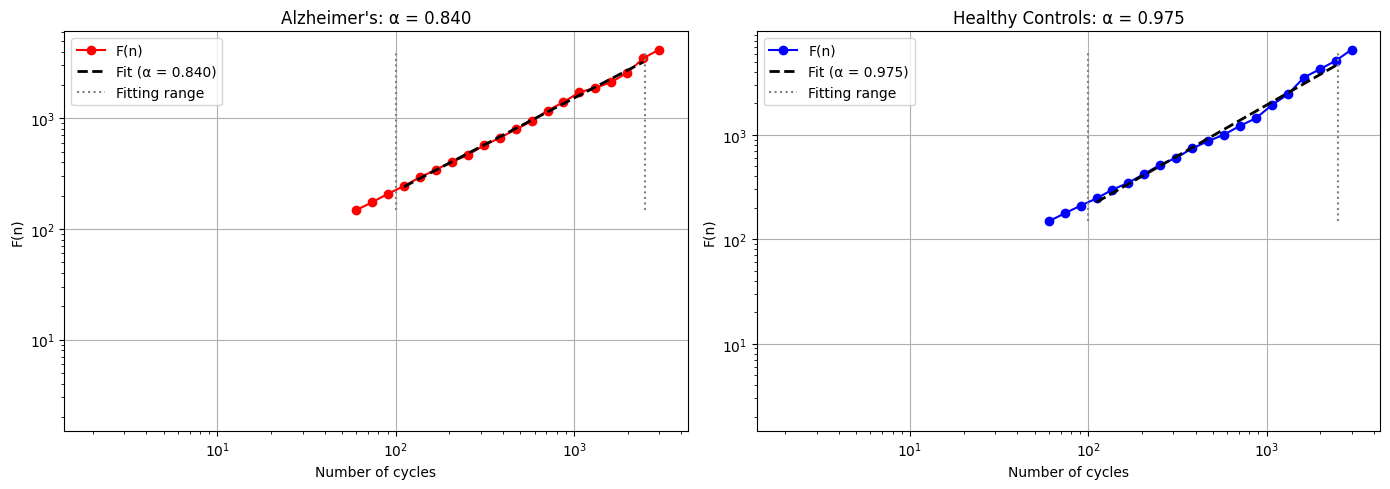

AD α = 0.840
HC α = 0.975
α ≈ 0.5 → white noise | 0.5 < α < 1 → correlated (critical) | α > 1 → random walk


In [ ]:
fitting_range = (2000, 50000)

alpha_ad, intercept_ad = compute_DFA(segment_sizes, F_ad, fitting_range)
alpha_hc, intercept_hc = compute_DFA(segment_sizes, F_hc, fitting_range)

n_cycles = segment_sizes * freq / sampling_rate
idx_fit = (segment_sizes > fitting_range[0]) & (segment_sizes < fitting_range[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, F, alpha, intercept, label, color in [
    (axes[0], F_ad, alpha_ad, intercept_ad, "Alzheimer's", 'red'),
    (axes[1], F_hc, alpha_hc, intercept_hc, 'Healthy Controls', 'blue'),
]:
    fit_sizes = segment_sizes[idx_fit]
    fit_cycles = fit_sizes * freq / sampling_rate
    fit_line = 10 ** (intercept + alpha * np.log10(fit_sizes))

    ax.loglog(n_cycles, F, 'o-', color=color, label='F(n)')
    ax.loglog(fit_cycles, fit_line, 'k--', linewidth=2, label=f'Fit (α = {alpha:.3f})')
    ax.vlines(fitting_range[0] * freq / sampling_rate, F.min(), F.max(),
              colors='gray', linestyles='dotted', label='Fitting range')
    ax.vlines(fitting_range[1] * freq / sampling_rate, F.min(), F.max(),
              colors='gray', linestyles='dotted')
    ax.set_xlabel('Number of cycles')
    ax.set_ylabel('F(n)')
    ax.set_title(f'{label}: α = {alpha:.3f}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

print(f"AD α = {alpha_ad:.3f}")
print(f"HC α = {alpha_hc:.3f}")
print(f"α ≈ 0.5 → white noise | 0.5 < α < 1 → correlated (critical) | α > 1 → random walk")